In [48]:
# Import Packages
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, SystemMessage, ToolMessage
from tavily import TavilyClient
from dotenv.ipython import load_dotenv
from IPython.display import Markdown
import os
from pprint import pprint

In [56]:
# Import ApIKeys
load_dotenv(".env")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [64]:
# Prepare The MIND LLMs
# basic_mind = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, max_tokens=4696, api_key=GOOGLE_API_KEY)
# advanced_mind = ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0, max_tokens=4696, api_key=GOOGLE_API_KEY)
basic_groq_llm = ChatGroq(model="qwen/qwen3-32b", temperature=0, max_tokens=None, reasoning_format="parsed",timeout=None, max_retries=2)

In [51]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

#### Agent for generating marketing offres

In [52]:
# Prepare The Body - Tools

@tool
def get_client_data(name: str):
    # Search on Data Base About Client
    '''
        Get Client Information About Marketing
    '''
    data = {
        "client_id": 12548,
        "fullName": name,
        "age": 34,
        "gender": "Male",
        "city": "Casablanca",
        "phone": "+212612345678",
        "email": "ahmed.elamrani@gmail.com",

        "customer_since": "2021-03-15",
        "last_purchase_date": "2026-06-20",
        "total_orders": 18,
        "total_spent": 24500,
        "average_order_value": 1361,

        "favorite_category": "Electronics",
        "favorite_brand": "Samsung",
        "purchase_frequency": "Monthly",

        "last_products": [
            "Samsung Galaxy S25",
            "Galaxy Buds Pro",
            "Wireless Charger"
        ],

        "loyalty_points": 3200,
        "membership": "Gold",

        "preferred_channel": "WhatsApp",
        "marketing_opt_in": True
    }
    return data


@tool
def tips_for_marketing_offre(query: str):
    '''
        Return List of Best Practices for generate marketing offre
    '''
    try:
        results = tavily_client.search(query=query)
        formatted_result = []
        for i, content in enumerate(results.get("results")):
            formatted_result.append(f"url: {content.get("url")}, title: {content.get("title")}, content: {content.get("content")}")
        return {"results": "\n".join(formatted_result)}
    except:
        return {"results": "WebSearch Tool Can Not get Informations"}


In [53]:
result = tips_for_marketing_offre.func("How is abdellah karani ?")
# pprint(result)

In [54]:
# Create Agent
sys_prompt = """
        You are a Marketing AI Agent specialized in generating personalized marketing offers.
        When a user requests a marketing offer:
            1. First retrieve the customer information using getClientData.
            2. Analyze customer profile
            3. generate marketing offre
            4. Generate a personalized marketing offer.
"""

marketing_agent = create_agent(
    model=basic_groq_llm,
    tools=[get_client_data, tips_for_marketing_offre],
    system_prompt=sys_prompt,
    debug=True
)

In [55]:
# Ask Agent
config = {"configurable": {"thread_id": 1}}
res = marketing_agent.invoke(
    input={"messages": [HumanMessage("Generate Marketing Offre for Abdellah Karani.")]},
    config=config
)
display(Markdown(res["messages"][-1].content))

[values] {'messages': [HumanMessage(content='Generate Marketing Offre for Abdellah Karani.', additional_kwargs={}, response_metadata={}, id='0fb27315-dc69-4f06-b014-f01b63d82331')]}


BadRequestError: Error code: 400 - {'error': {'message': '`reasoning_format` is not supported with this model', 'type': 'invalid_request_error', 'param': 'reasoning_format'}}

#### Agent de Scoring

In [ ]:
# Tools
@tool
def get_client_data_for_scoring(name):
    '''
        Get customer information for scoring between 0 and 100
    '''
    data = {
        "name": "Sophie Martin",
        "company": "Tech Solutions",
        "sector": "IT",
        "employees": 45,
        "revenue": 3200000,
        
        # Purchase behavior
        "last_purchase": "2026-06-28",
        "total_purchases": 12,
        "total_spent": 28450,
        "avg_basket": 2370,
        "purchase_frequency_months": 2.5,
        
        # Engagement
        "email_open_rate": 0.68,
        "click_rate": 0.32,
        "website_visits_30d": 18,
        "time_on_site_min": 6.5,
        "cart_abandonments": 2,
        
        # Risk indicators
        "payment_delay_days": 0,
        "support_tickets": 1,
        "satisfaction_score": 4.5,
        "credit_score": 780,
        "competitor_mentions": 0,
        
        # Contract
        "contract_end": "2027-01-15",
        "has_app": True,
        "subscribed": True
    } 
    return data



In [ ]:
# Create agent
sys_prompt = """
        You are a Scroing AI Agent specialized in give personalized score to each client.
        When a user requests a scoring offer:
            1. First Get All cutomer data
            2. Analyze customer profile
            3. give score to this customer
            4. at end give feedback about this user
"""
scoring_agent = create_agent(
    model= basic_groq_llm,
    system_prompt=sys_prompt,
    tools=[get_client_data_for_scoring],
    debug=True,
)

In [ ]:
# Invoke a question
config = {"configurable": {"thread_id": 1}}
resp = scoring_agent.invoke(
    input={"messages": [HumanMessage("give to this client abdellah karani a score ?")]},
    config = config
)
display(Markdown(resp["messages"][-1].content))

[values] {'messages': [HumanMessage(content='give to this client abdellah karani a score ?', additional_kwargs={}, response_metadata={}, id='69d6f128-7076-4bea-b6cc-34333b2a35fb')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants a score for the client named Abdellah Karani. Let me start by recalling the steps I need to follow. First, I need to get all the customer data using the provided function. The function is called get_client_data_for_scoring and it requires the name parameter. Since the user provided the name "abdellah karani", I should call this function with that exact name.\n\nWait, I should check if the function is correctly structured. The tool\'s JSON shows that the function takes a "name" property in the parameters. The required field is "name", and the type is an object. So, the correct way to call it is to pass the name as a JSON object with the key "name" and the value "abdellah karani".\n\nI need to

**Score for Sophie Martin (Tech Solutions): 88/100**

**Feedback:**  
Sophie Martin from Tech Solutions is a **high-value client** with strong engagement and reliability. Key strengths include:  
- **Loyal purchasing behavior**: 12 total purchases, frequent (every 2.5 months), and high average basket ($2,370).  
- **Excellent payment discipline**: No payment delays and a strong credit score (780).  
- **High engagement**: 68% email open rate, 32% click rate, and active website visits (18 in 30 days).  
- **Low churn risk**: No competitor mentions and a contract valid until 2027.  

**Areas to monitor**:  
- **Cart abandonment**: 2 instances may indicate friction in the purchase process.  
- **Contract renewal**: Proactively engage before January 2027 to ensure retention.  

Overall, a **low-risk, high-potential client** worth prioritizing for upselling and long-term partnerships.

#### Build MultiAgent From Scratch

In [ ]:
# Import Package
from typing import Annotated, Sequence, List, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
# The State
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [ ]:
# Create Agent With Tools
@tool
def add(a: float, b: float):
    """Return the sum of a and b."""
    return {"operation": "add", "a": a, "b": b, "result": a + b}

@tool
def subtract(a: float, b: float):
    """Return the difference a - b."""
    return {"operation": "subtract", "a": a, "b": b, "result": a - b}

@tool
def multiply(a: float, b: float):
    """Return the product of a and b."""
    return {"operation": "multiply", "a": a, "b": b, "result": a * b}

@tool
def divide(a: float, b: float):
    """Return the quotient a / b or an error if b is zero."""
    if b == 0:
        return {"operation": "divide", "a": a, "b": b, "error": "division by zero"}
    return {"operation": "divide", "a": a, "b": b, "result": a / b}

tools = [add, multiply, divide, subtract]

In [ ]:
# LLM with Tools
llm_with_tools = ChatGroq(model="qwen/qwen3-32b", temperature=0).bind_tools(tools)

In [ ]:
# Create Node For Agent
def assistant(state: AgentState):
    system_message = SystemMessage("Answer the question using tools only.")
    print("State is: ", state)
    response = llm_with_tools.invoke([system_message] + state["messages"])
    return {"messages": [response]}

In [ ]:
# Descion
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    print("Call Should Continue with Tools: ", last_message.tool_calls)
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

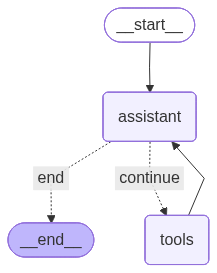

In [ ]:
# Build, Compile and Display the Graph
agent_workflow = StateGraph(AgentState)

agent_workflow.add_node("assistant", assistant)
agent_workflow.add_node("tools", ToolNode(tools=tools))

agent_workflow.add_edge(START, "assistant")
agent_workflow.add_conditional_edges("assistant",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)

agent_workflow.add_edge("tools", "assistant")

checkpointer = MemorySaver()
graph = agent_workflow.compile(checkpointer=checkpointer)
display(Image(graph.get_graph().draw_mermaid_png()))

In [65]:
# get responses
config = {"configurable": {"thread_id": 1}}
resp = graph.invoke(input={"messages": [HumanMessage("do all mathematical operation on this numbers 2 and 5")]}, config=config)
print(resp["messages"][-1].content)

State is:  {'messages': [HumanMessage(content='do all mathematical operation on this numbers 2 and 5', additional_kwargs={}, response_metadata={}, id='ac35e4b3-5835-4d0e-95fb-2803884288ed'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants me to perform all mathematical operations on the numbers 2 and 5. Let me check the available functions. There's add, multiply, divide, and subtract.\n\nFirst, I'll call the add function with a=2 and b=5. That should give 7. Next, multiply 2 and 5 to get 10. Then, subtract 5 from 2, which results in -3. Finally, divide 2 by 5. Since 5 isn't zero, the quotient should be 0.4. I need to make sure each function is called correctly and handle any potential errors, but in this case, division is safe. I'll return each result step by step.\n", 'tool_calls': [{'id': 'vwh24jm9h', 'function': {'arguments': '{"a":2,"b":5}', 'name': 'add'}, 'type': 'function'}, {'id': 'pthd827fr', 'function': {'arguments': '{"a":2,"b":5}', 'name'